In [1]:
#Importing the libraries that may be helpful for this project.

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.io import fits

XTENSION= 'IMAGE   '           / Image extension                                BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                  605                                                  NAXIS2  =                  897                                                  PCOUNT  =                    0 / number of parameters                           GCOUNT  =                    1 / number of groups                               CD1_1   = -5.5555555555556E-05                                                  CD2_2   =  5.5555555555556E-05                                                  CRVAL1  =      353.62249670367                                                  CRVAL2  =     -36.100403943522                                                  CRPIX1  =      161.73318277819                                                  CRPIX2  =      450.04690107766          

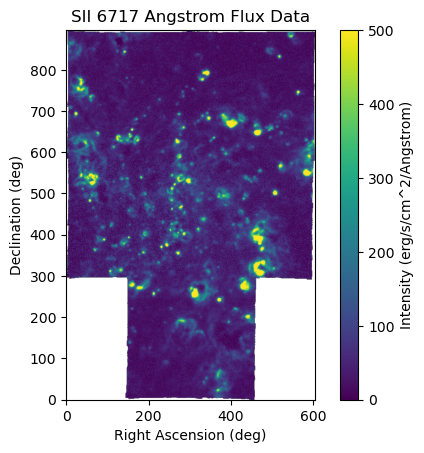

XTENSION= 'IMAGE   '           / Image extension                                BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                  605                                                  NAXIS2  =                  897                                                  PCOUNT  =                    0 / number of parameters                           GCOUNT  =                    1 / number of groups                               CD1_1   = -5.5555555555556E-05                                                  CD2_2   =  5.5555555555556E-05                                                  CRVAL1  =      353.62249670367                                                  CRVAL2  =     -36.100403943522                                                  CRPIX1  =      161.73318277819                                                  CRPIX2  =      450.04690107766          

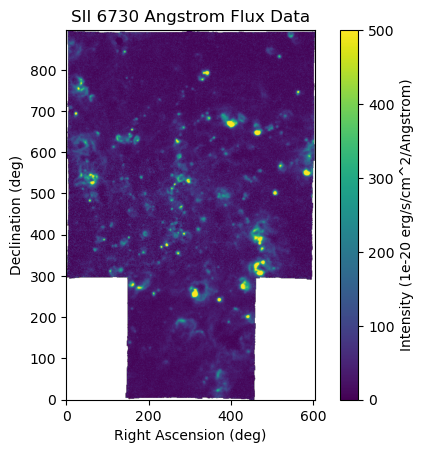

XTENSION= 'IMAGE   '           / Image extension                                BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                  605                                                  NAXIS2  =                  897                                                  PCOUNT  =                    0 / number of parameters                           GCOUNT  =                    1 / number of groups                               CD1_1   = -5.5555555555556E-05                                                  CD2_2   =  5.5555555555556E-05                                                  CRVAL1  =      353.62249670367                                                  CRVAL2  =     -36.100403943522                                                  CRPIX1  =      161.73318277819                                                  CRPIX2  =      450.04690107766          

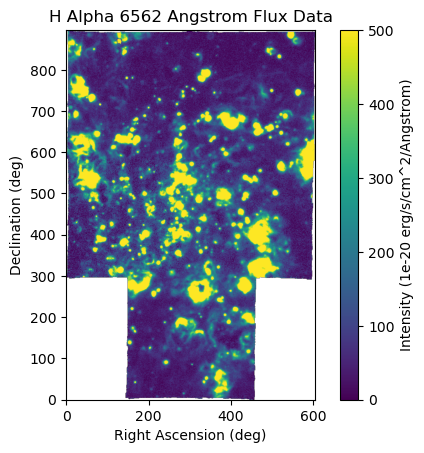

The minimum ratio of Sulfur to H alpha intensity is about .40.
This data shows strong correlation with SNR nebulae. The mean ratios are 0.71 at 6717 Angstroms and 0.57 at 6730 Angstroms with respective medians of 0.40 and 0.28.


In [6]:
#Graphing the lower wavelength sulfur fits graph. It graphs intensity as color, with location as the x and y axes.

with fits.open("subset.fits") as hdul:
    header = hdul[0].header
    datastack = hdul[2].data
    
    ###This is me looking through the data for the values I wanted.
    #for x in range(1, 54):
    #    data = hdul[x].data
    #    datastack = datastack + data
    #    header = hdul[x].header
    #    print(header)
    #    print(f"END OF {x}")

    #Printing information about the data collection.
    print(hdul[2].header)

    #Making the graph.
    plt.imshow(datastack, cmap='viridis', origin='lower', vmax = 500) 
    plt.colorbar(label='Intensity (erg/s/cm^2/Angstrom)') 
    plt.title('SII 6717 Angstrom Flux Data')
    plt.xlabel('Right Ascension (deg)')
    plt.ylabel('Declination (deg)')
    plt.show()

#This is for the higher wavelength sulfur.

with fits.open("subset.fits") as hdul:
    header = hdul[0].header
    data = hdul[3].data
    
    print(hdul[3].header)
    
    plt.imshow(data, cmap='viridis', origin='lower', vmax = 500) 
    plt.colorbar(label='Intensity (1e-20 erg/s/cm^2/Angstrom)')
    plt.title('SII 6730 Angstrom Flux Data')
    plt.xlabel('Right Ascension (deg)')
    plt.ylabel('Declination (deg)')
    plt.show()

#This is for the H alpha emission, our "reference point". We use it as the baseline and divide by it to get a ratio to standardize it across measurements
#by different telescopes and in different projects.

with fits.open("subset.fits") as hdul:
    header = hdul[0].header
    data = hdul[1].data
    
    print(hdul[1].header)
    
    plt.imshow(data, cmap='viridis', origin='lower', vmax = 500)
    plt.colorbar(label='Intensity (1e-20 erg/s/cm^2/Angstrom)') 
    plt.title('H Alpha 6562 Angstrom Flux Data')
    plt.xlabel('Right Ascension (deg)')
    plt.ylabel('Declination (deg)')
    plt.show()

#Division of the SII 6730 map and H Alpha map, then finding the mean and median.
with fits.open("subset.fits") as hdul:
    #Receiving the sulfur and H alpha data from the fits files.
    data1 = hdul[3].data
    data2 = hdul[1].data

    #Dividing non-zero values.
    division_result = np.divide(data1, data2, where = (data2 != 0))

    #Removing any values that are 0 in the first or second values.
    filtered_division = division_result[(division_result != 0) & np.isfinite(division_result)]

    #Storing the mean and median of the kept ratios.
    mean_1 = np.mean(filtered_division)
    median_1 = np.median(filtered_division)
    
#Doing the same thing with SII 6717
with fits.open("subset.fits") as hdul:
    data1 = hdul[2].data
    data2 = hdul[1].data
    division_result = np.divide(data1, data2, where = (data2 != 0))
    
    filtered_division = division_result[(division_result != 0) & np.isfinite(division_result)]
    
    mean_2 = np.mean(filtered_division)
    median_2 = np.median(filtered_division)

#Printing the results based on how many values are above the minimum of .40.
print("The minimum ratio of Sulfur to H alpha intensity is about .40.")
if mean_1 > .40 and mean_2 > .40:
    print(f"This data shows strong correlation with SNR nebulae. The mean ratios are {mean_2:.2f} at 6717 Angstroms and {mean_1:.2f} at 6730 Angstroms with respective medians of {median_2:.2f} and {median_1:.2f}.")
elif mean_1 > .40 or mean_2 > .40:
    print(f"This data shows some correlation with SNR nebulae. The mean ratios are {mean_2:.2f} at 6717 Angstroms and {mean_1:.2f} at 6730 Angstroms with respective medians of {median_2:.2f} and {median_1:.2f}.")
else: print(f"This data shows no correlation with SNR nebulae. The mean ratios are {mean_2:.2f} at 6717 Angstroms and {mean_1:.2f} at 6730 Angstroms with respective medians of {median_2:.2f} and {median_1:.2f}.")

XTENSION= 'IMAGE   '           / Image extension                                BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                  605                                                  NAXIS2  =                  897                                                  PCOUNT  =                    0 / number of parameters                           GCOUNT  =                    1 / number of groups                               CD1_1   = -5.5555555555556E-05                                                  CD2_2   =  5.5555555555556E-05                                                  CRVAL1  =      353.62249670367                                                  CRVAL2  =     -36.100403943522                                                  CRPIX1  =      161.73318277819                                                  CRPIX2  =      450.04690107766          

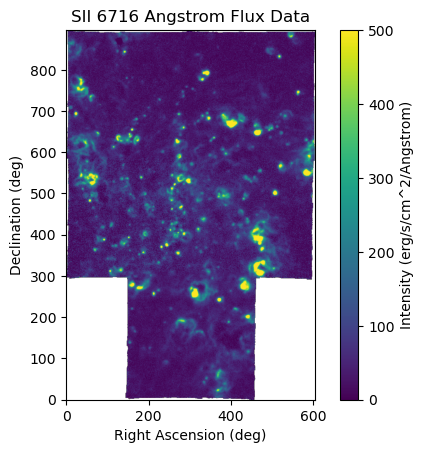

XTENSION= 'IMAGE   '           / Image extension                                BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                  605                                                  NAXIS2  =                  897                                                  PCOUNT  =                    0 / number of parameters                           GCOUNT  =                    1 / number of groups                               CD1_1   = -5.5555555555556E-05                                                  CD2_2   =  5.5555555555556E-05                                                  CRVAL1  =      353.62249670367                                                  CRVAL2  =     -36.100403943522                                                  CRPIX1  =      161.73318277819                                                  CRPIX2  =      450.04690107766          

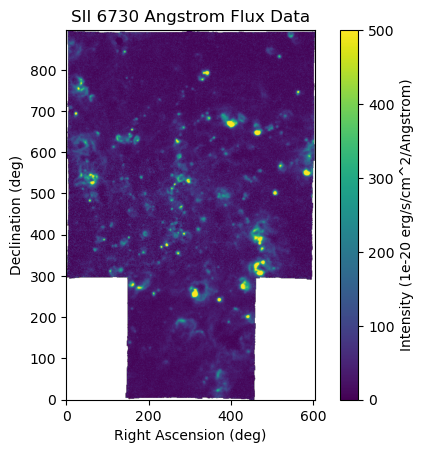

XTENSION= 'IMAGE   '           / Image extension                                BITPIX  =                  -64 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                  605                                                  NAXIS2  =                  897                                                  PCOUNT  =                    0 / number of parameters                           GCOUNT  =                    1 / number of groups                               CD1_1   = -5.5555555555556E-05                                                  CD2_2   =  5.5555555555556E-05                                                  CRVAL1  =      353.62249670367                                                  CRVAL2  =     -36.100403943522                                                  CRPIX1  =      161.73318277819                                                  CRPIX2  =      450.04690107766          

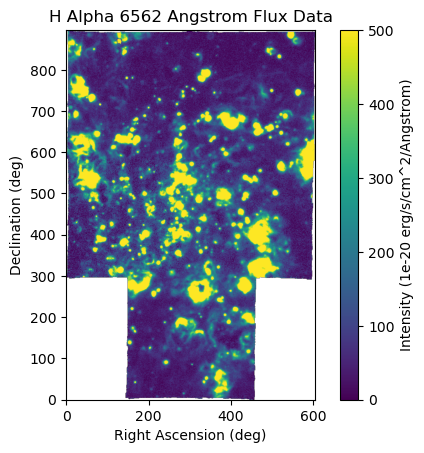

The minimum ratio of Sulfur to H alpha intensity is about .40.
This data shows strong correlation with SNR nebulae. The mean ratios are 0.71 at 6717 Angstroms and 0.57 at 6730 Angstroms with respective medians of 0.40 and 0.28.


In [70]:
#This is from the original fits file that is not attached. It was too big for github.

#Graphing the lower wavelength sulfur fits graph. It graphs intensity as color, with location as the x and y axes.

with fits.open("IC5332_MAPS_native.fits") as hdul:
    header = hdul[0].header
    datastack = hdul[42].data
    
    ###This is me looking through the data for the values I wanted.
    #for x in range(1, 54):
    #    data = hdul[x].data
    #    datastack = datastack + data
    #    header = hdul[x].header
    #    print(header)
    #    print(f"END OF {x}")

    #Printing information about the data collection.
    print(hdul[42].header)

    #Making the graph.
    plt.imshow(datastack, cmap='viridis', origin='lower', vmax = 500) 
    plt.colorbar(label='Intensity (erg/s/cm^2/Angstrom)') 
    plt.title('SII 6717 Angstrom Flux Data')
    plt.xlabel('Right Ascension (deg)')
    plt.ylabel('Declination (deg)')
    plt.show()

#This is for the higher wavelength sulfur.

with fits.open("IC5332_MAPS_native.fits") as hdul:
    header = hdul[0].header
    data = hdul[48].data
    
    print(hdul[48].header)
    
    plt.imshow(data, cmap='viridis', origin='lower', vmax = 500) 
    plt.colorbar(label='Intensity (1e-20 erg/s/cm^2/Angstrom)')
    plt.title('SII 6730 Angstrom Flux Data')
    plt.xlabel('Right Ascension (deg)')
    plt.ylabel('Declination (deg)')
    plt.show()

#This is for the H alpha emission, our "reference point". We use it as the baseline and divide by it to get a ratio to standardize it across measurements
#by different telescopes and in different projects.

with fits.open("IC5332_MAPS_native.fits") as hdul:
    header = hdul[0].header
    data = hdul[30].data
    
    print(hdul[30].header)
    
    plt.imshow(data, cmap='viridis', origin='lower', vmax = 500)
    plt.colorbar(label='Intensity (1e-20 erg/s/cm^2/Angstrom)') 
    plt.title('H Alpha 6562 Angstrom Flux Data')
    plt.xlabel('Right Ascension (deg)')
    plt.ylabel('Declination (deg)')
    plt.show()

#Division of the SII 6730 map and H Alpha map, then finding the mean and median.
with fits.open("IC5332_MAPS_native.fits") as hdul:
    #Receiving the sulfur and H alpha data from the fits files.
    data1 = hdul[48].data
    data2 = hdul[30].data

    #Dividing non-zero values.
    division_result = np.divide(data1, data2, where = (data2 != 0))

    #Removing any values that are 0 in the first or second values.
    filtered_division = division_result[(division_result != 0) & np.isfinite(division_result)]

    #Storing the mean and median of the kept ratios.
    mean_1 = np.mean(filtered_division)
    median_1 = np.median(filtered_division)
    
#Doing the same thing with SII 6717
with fits.open("IC5332_MAPS_native.fits") as hdul:
    data1 = hdul[42].data
    data2 = hdul[30].data
    division_result = np.divide(data1, data2, where = (data2 != 0))
    
    filtered_division = division_result[(division_result != 0) & np.isfinite(division_result)]
    
    mean_2 = np.mean(filtered_division)
    median_2 = np.median(filtered_division)

#Printing the results based on how many values are above the minimum of .40.
print("The minimum ratio of Sulfur to H alpha intensity is about .40.")
if mean_1 > .40 and mean_2 > .40:
    print(f"This data shows strong correlation with SNR nebulae. The mean ratios are {mean_2:.2f} at 6717 Angstroms and {mean_1:.2f} at 6730 Angstroms with respective medians of {median_2:.2f} and {median_1:.2f}.")
elif mean_1 > .40 or mean_2 > .40:
    print(f"This data shows some correlation with SNR nebulae. The mean ratios are {mean_2:.2f} at 6717 Angstroms and {mean_1:.2f} at 6730 Angstroms with respective medians of {median_2:.2f} and {median_1:.2f}.")
else: print(f"This data shows no correlation with SNR nebulae. The mean ratios are {mean_2:.2f} at 6717 Angstroms and {mean_1:.2f} at 6730 Angstroms with respective medians of {median_2:.2f} and {median_1:.2f}.")

In [4]:
with fits.open("IC5332_MAPS_native.fits") as hdul:
    selected_hdus = [hdul[i] for i in [0,30, 42, 48]]
    new_hdul = fits.HDUList(selected_hdus)
    new_hdul.writeto("subset.fits", overwrite=True)